In [2]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

In [16]:
#Load dataset

df = pd.read_csv(r"C:\Users\yasha\Downloads\cic-ids\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
print("Initial shape:", df.shape)
print(df.head())
# Clean column names by removing leading/trailing spaces
df.columns = df.columns.str.strip()

Initial shape: (225745, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0              54865               3                   2   
1              55054             109                   1   
2              55055              52                   1   
3              46236              34                   1   
4              54863               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        1                            6   
2                        1                            6   
3                        1                            6   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1                             6                       6   
2                             6                       6   
3                   

In [3]:
#Load dataset

df = pd.read_csv(r"C:\Users\yasha\Downloads\cic-ids\Wednesday-workingHours.pcap_ISCX.csv")
print("Initial shape:", df.shape)
print(df.head())
# Clean column names by removing leading/trailing spaces
df.columns = df.columns.str.strip()


Initial shape: (692703, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0                 80           38308                   1   
1                389             479                  11   
2                 88            1095                  10   
3                389           15206                  17   
4                 88            1092                   9   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        1                            6   
1                        5                          172   
2                        6                         3150   
3                       12                         3452   
4                        6                         3150   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             6                       6   
1                           326                      79   
2                          3150                    1575   
3                   

In [4]:
# Clean column names (remove spaces/newlines)
df.columns = df.columns.str.strip()

# Force the correct label column name
if "Label" not in df.columns:
    df.rename(columns={df.columns[-1]: "Label"}, inplace=True)

label_col = "Label"


In [5]:
# Display first few rows
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [6]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692703 entries, 0 to 692702
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             692703 non-null  int64  
 1   Flow Duration                692703 non-null  int64  
 2   Total Fwd Packets            692703 non-null  int64  
 3   Total Backward Packets       692703 non-null  int64  
 4   Total Length of Fwd Packets  692703 non-null  int64  
 5   Total Length of Bwd Packets  692703 non-null  int64  
 6   Fwd Packet Length Max        692703 non-null  int64  
 7   Fwd Packet Length Min        692703 non-null  int64  
 8   Fwd Packet Length Mean       692703 non-null  float64
 9   Fwd Packet Length Std        692703 non-null  float64
 10  Bwd Packet Length Max        692703 non-null  int64  
 11  Bwd Packet Length Min        692703 non-null  int64  
 12  Bwd Packet Length Mean       692703 non-null  float64
 13 

In [7]:
# Identify label column

# Class distribution
label_dist = df[label_col].value_counts()
label_dist_pct = df[label_col].value_counts(normalize=True) * 100

label_dist, label_dist_pct.round(2)

(Label
 BENIGN              440031
 DoS Hulk            231073
 DoS GoldenEye        10293
 DoS slowloris         5796
 DoS Slowhttptest      5499
 Heartbleed              11
 Name: count, dtype: int64,
 Label
 BENIGN              63.52
 DoS Hulk            33.36
 DoS GoldenEye        1.49
 DoS slowloris        0.84
 DoS Slowhttptest     0.79
 Heartbleed           0.00
 Name: proportion, dtype: float64)


 Normal vs Attack Distribution (Binary)


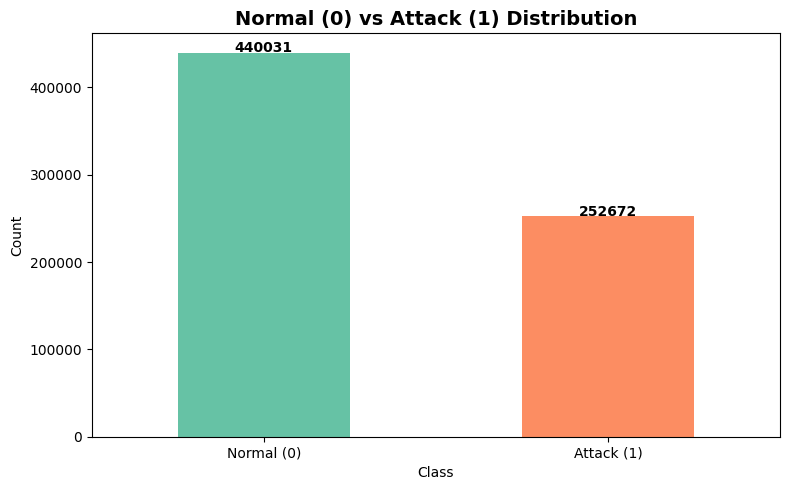

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Normal vs Attack Distribution ---
print("\n Normal vs Attack Distribution (Binary)")
print("="*80)

# Convert to binary
y_binary = df[label_col].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Use Set2 palette with 2 colors
colors = sns.color_palette("Set2", 2)

# Plot Normal vs Attack
plt.figure(figsize=(8,5))
y_binary.value_counts().plot(kind='bar', color=colors)
plt.grid(False)
plt.title('Normal (0) vs Attack (1) Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0,1], ['Normal (0)', 'Attack (1)'], rotation=0)


# Add value labels
for i, v in enumerate(y_binary.value_counts().values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


Top Attack Types (Multi-class)


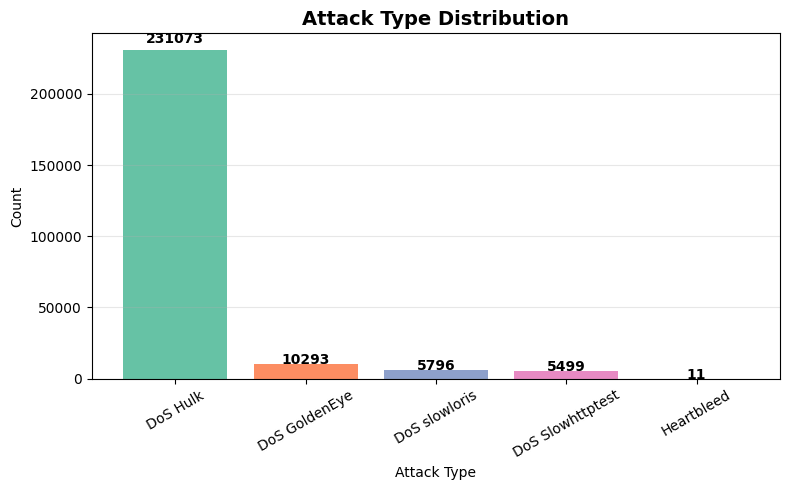

In [9]:
# --- Top Attack Types (Multi-class) ---
print("\nTop Attack Types (Multi-class)")
print("="*80)

attack_df = df[df[label_col] != 'BENIGN'][label_col].value_counts()

if len(attack_df) == 0:
    print("No attack records found in dataset.")
elif len(attack_df) == 1:
    print("Only one attack class found:", attack_df.index[0])

attack_types = attack_df.head(10)

plt.figure(figsize=(8,5))
bars = plt.bar(attack_types.index, attack_types.values,
               color=sns.color_palette("Set2", n_colors=len(attack_types)))

plt.title('Attack Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(attack_types.values):
    plt.text(i, v + v*0.02, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


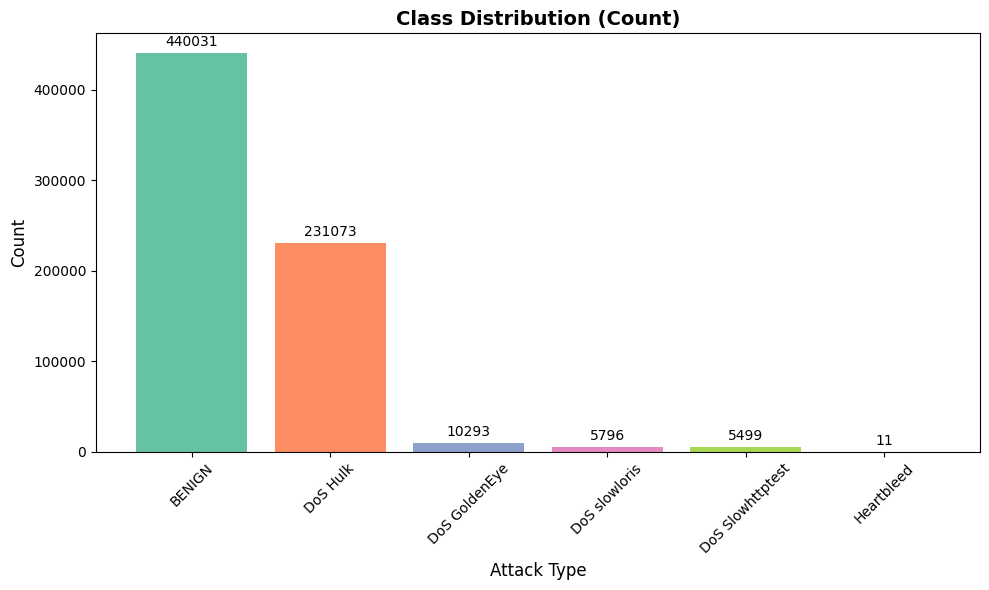

In [9]:
## Class Distribution (Count) – Bar Chart

import seaborn as sns
import matplotlib.pyplot as plt

colors = sns.color_palette("Set2", n_colors=len(label_dist))

plt.figure(figsize=(10,6))
bars = plt.bar(label_dist.index, label_dist.values, color=colors)

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01*max(label_dist.values),
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.title('Class Distribution (Count)', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

# Remove grid
plt.grid(False)

plt.tight_layout()
plt.show()

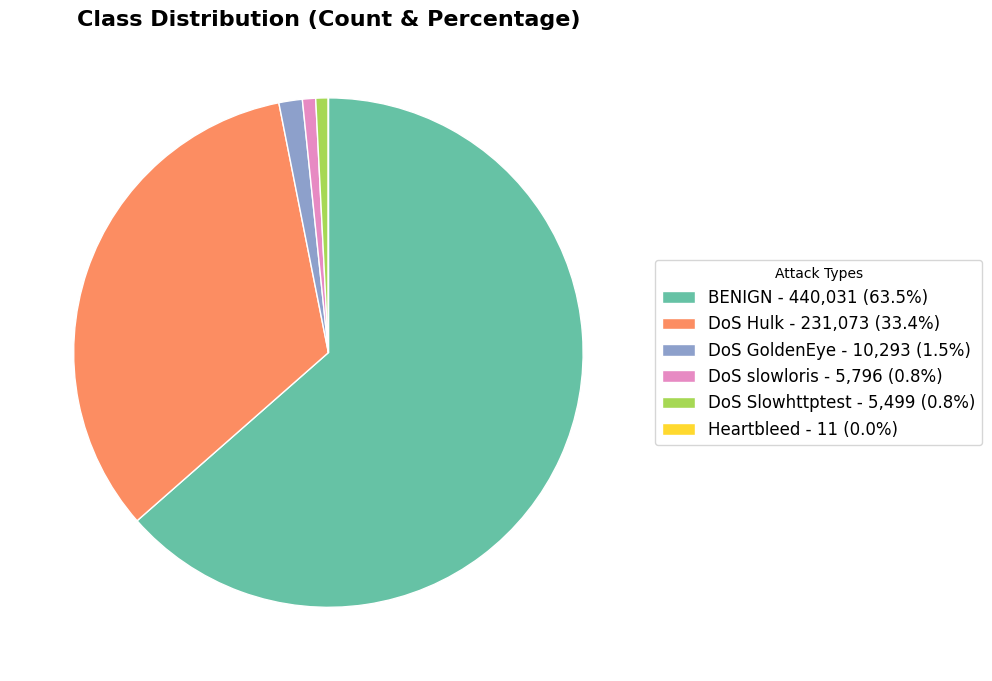

In [10]:
## Class Distribution (Percentage) – Pie Chart

import seaborn as sns
import matplotlib.pyplot as plt

colors = sns.color_palette("Set2", n_colors=len(label_dist))

plt.figure(figsize=(10,10))

# Draw pie chart without labels inside
wedges, texts = plt.pie(
    label_dist.values,
    colors=colors,
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'white'}
)

# Add a legend outside with labels and percentages
labels_with_pct = [f"{l} - {v:,} ({v/sum(label_dist.values)*100:.1f}%)" 
                   for l, v in zip(label_dist.index, label_dist.values)]
plt.legend(wedges, labels_with_pct,
           title="Attack Types",
           loc="center left",
           bbox_to_anchor=(1, 0.5),
           fontsize=12)

plt.title('Class Distribution (Count & Percentage)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
## Check Data Quality
# Missing values
missing_values = df.isnull().sum()
missing_pct = (missing_values / len(df)) * 100
missing_summary = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values,
    'Percentage': missing_pct.values
})
missing_summary[missing_summary['Missing_Count'] > 0]

,Column,Missing_Count,Percentage
14,Flow Bytes/s,1008,0.145517


In [17]:
#Drop unnecessary columns

to_drop = ["Flow ID", "Source IP", "Destination IP", "Timestamp"]
df.drop([col for col in to_drop if col in df.columns], axis=1, inplace=True)

In [18]:
#Handle nan values and infinite values

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print("After cleaning:", df.shape)

After cleaning: (225711, 79)


In [19]:
#Encode Target Column
encoder = LabelEncoder()
df["Label"] = encoder.fit_transform(df["Label"])
print("Classes:", encoder.classes_)
     

Classes: ['BENIGN' 'DDoS']


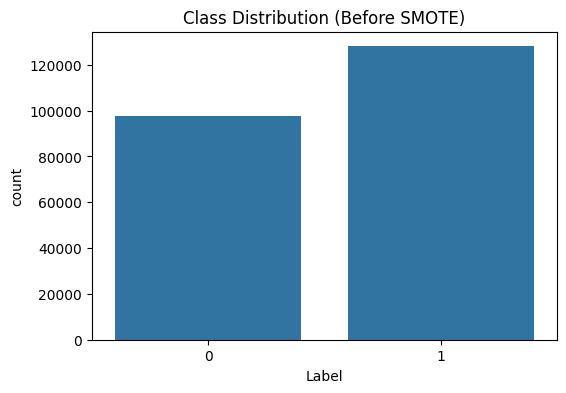

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Label"])
plt.title("Class Distribution (Before SMOTE)")
plt.show()


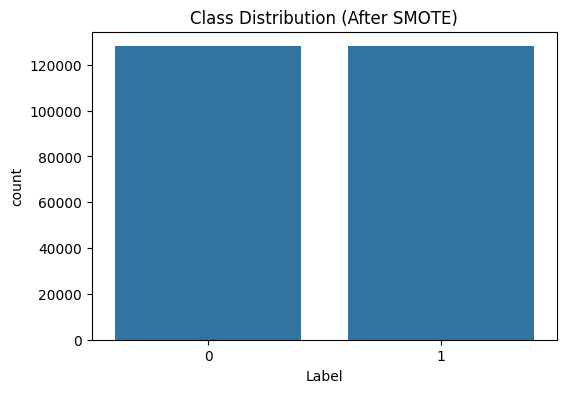

In [21]:
#Split target and features

X = df.drop("Label", axis=1)
y = df["Label"]

# Handle class imbalance
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

plt.figure(figsize=(6,4))
sns.countplot(x=y_res)
plt.title("Class Distribution (After SMOTE)")
plt.show()

In [22]:
#Feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)

In [23]:
##Split train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_res, test_size=0.2, random_state=42, stratify=y_res
)

In [48]:
# Dimensionality reduction

pca = PCA(n_components=20, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [49]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        solver='lbfgs',
        C=1.0,
        n_jobs=-1
    ),

    "Stochastic Gradient Descent (SGDClassifier)": SGDClassifier(
        loss='log_loss',       
        learning_rate='optimal',
        alpha=0.0001,
        max_iter=2000,
        penalty='l2'
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=15,
        min_samples_split=5,
        criterion='gini'
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        n_jobs=-1
    ),

    "Naive Bayes": GaussianNB(),

    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        tree_method='hist'
    )
}

# Train & Evaluate All Models

for name, model in models.items():
    print("\n")
    print(f"Training {name}...")
    model.fit(X_train_pca, y_train)

    preds = model.predict(X_test_pca)
    acc = accuracy_score(y_test, preds)

    print(f"{name} Accuracy: {acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, preds))




Training Logistic Regression...
Logistic Regression Accuracy: 99.28%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     25605
           1       0.99      1.00      0.99     25605

    accuracy                           0.99     51210
   macro avg       0.99      0.99      0.99     51210
weighted avg       0.99      0.99      0.99     51210



Training Stochastic Gradient Descent (SGDClassifier)...
Stochastic Gradient Descent (SGDClassifier) Accuracy: 98.88%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     25605
           1       0.98      1.00      0.99     25605

    accuracy                           0.99     51210
   macro avg       0.99      0.99      0.99     51210
weighted avg       0.99      0.99      0.99     51210



Training Decision Tree...
Decision Tree Accuracy: 99.96%

Classification Report:
              precision  

In [56]:
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
import pandas as pd
import numpy as np

def get_metrics(model, X, y):
    preds = model.predict(X)

    # Probability or decision scores for AUC
    try:
        probs = model.predict_proba(X)[:, 1]
    except:
        try:
            probs = model.decision_function(X)
        except:
            probs = None

    accuracy = accuracy_score(y, preds)
    sensitivity = recall_score(y, preds)

    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    specificity = tn / (tn + fp)

    f1 = f1_score(y, preds)
    auc = roc_auc_score(y, probs) if probs is not None else np.nan

    return accuracy, sensitivity, specificity, f1, auc


# Collect TRAIN and TEST metrics separately
train_rows = []
test_rows = []

for name, model in models.items():
    print(f"Evaluating {name}...")

    # TRAIN metrics
    tr_acc, tr_sens, tr_spec, tr_f1, tr_auc = get_metrics(model, X_train_pca, y_train)
    train_rows.append([
        name,
        f"{tr_acc*100:.2f}%",
        f"{tr_sens*100:.2f}%",
        f"{tr_spec*100:.2f}%",
        f"{tr_f1*100:.2f}%",
        f"{tr_auc:.4f}" if not np.isnan(tr_auc) else "NA"
    ])

    # TEST metrics
    te_acc, te_sens, te_spec, te_f1, te_auc = get_metrics(model, X_test_pca, y_test)
    test_rows.append([
        name,
        f"{te_acc*100:.2f}%",
        f"{te_sens*100:.2f}%",
        f"{te_spec*100:.2f}%",
        f"{te_f1*100:.2f}%",
        f"{te_auc:.4f}" if not np.isnan(te_auc) else "NA"
    ])

train_df = pd.DataFrame(train_rows, columns=[
    "Model", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"
])

train_df = train_df.sort_values(by="Accuracy", ascending=False)
train_df.reset_index(drop=True, inplace=True)

print("\n TRAIN METRICS \n")
display(train_df)


test_df = pd.DataFrame(test_rows, columns=[
    "Model", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"
])

test_df = test_df.sort_values(by="Accuracy", ascending=False)
test_df.reset_index(drop=True, inplace=True)

print("\n TEST METRICS \n")
display(test_df)


Evaluating Logistic Regression...
Evaluating Stochastic Gradient Descent (SGDClassifier)...
Evaluating Decision Tree...
Evaluating Random Forest...
Evaluating Naive Bayes...
Evaluating XGBoost...

 TRAIN METRICS 



,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,Logistic Regression,99.29%,99.88%,98.70%,99.29%,0.9994
1,Stochastic Gradient Descent (SGDClassifier),98.88%,99.90%,97.87%,98.90%,0.9994
2,Naive Bayes,83.79%,94.98%,72.60%,85.42%,0.9590
3,Decision Tree,100.00%,100.00%,100.00%,100.00%,1.0000
4,Random Forest,100.00%,100.00%,100.00%,100.00%,1.0000
5,XGBoost,100.00%,100.00%,100.00%,100.00%,1.0000



 TEST METRICS 



,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,Random Forest,99.98%,99.96%,99.99%,99.98%,1.0000
1,XGBoost,99.98%,99.98%,99.98%,99.98%,1.0000
2,Decision Tree,99.96%,99.97%,99.96%,99.96%,0.9997
3,Logistic Regression,99.28%,99.86%,98.70%,99.28%,0.9993
4,Stochastic Gradient Descent (SGDClassifier),98.88%,99.88%,97.87%,98.89%,0.9993
5,Naive Bayes,83.78%,94.98%,72.58%,85.41%,0.9585


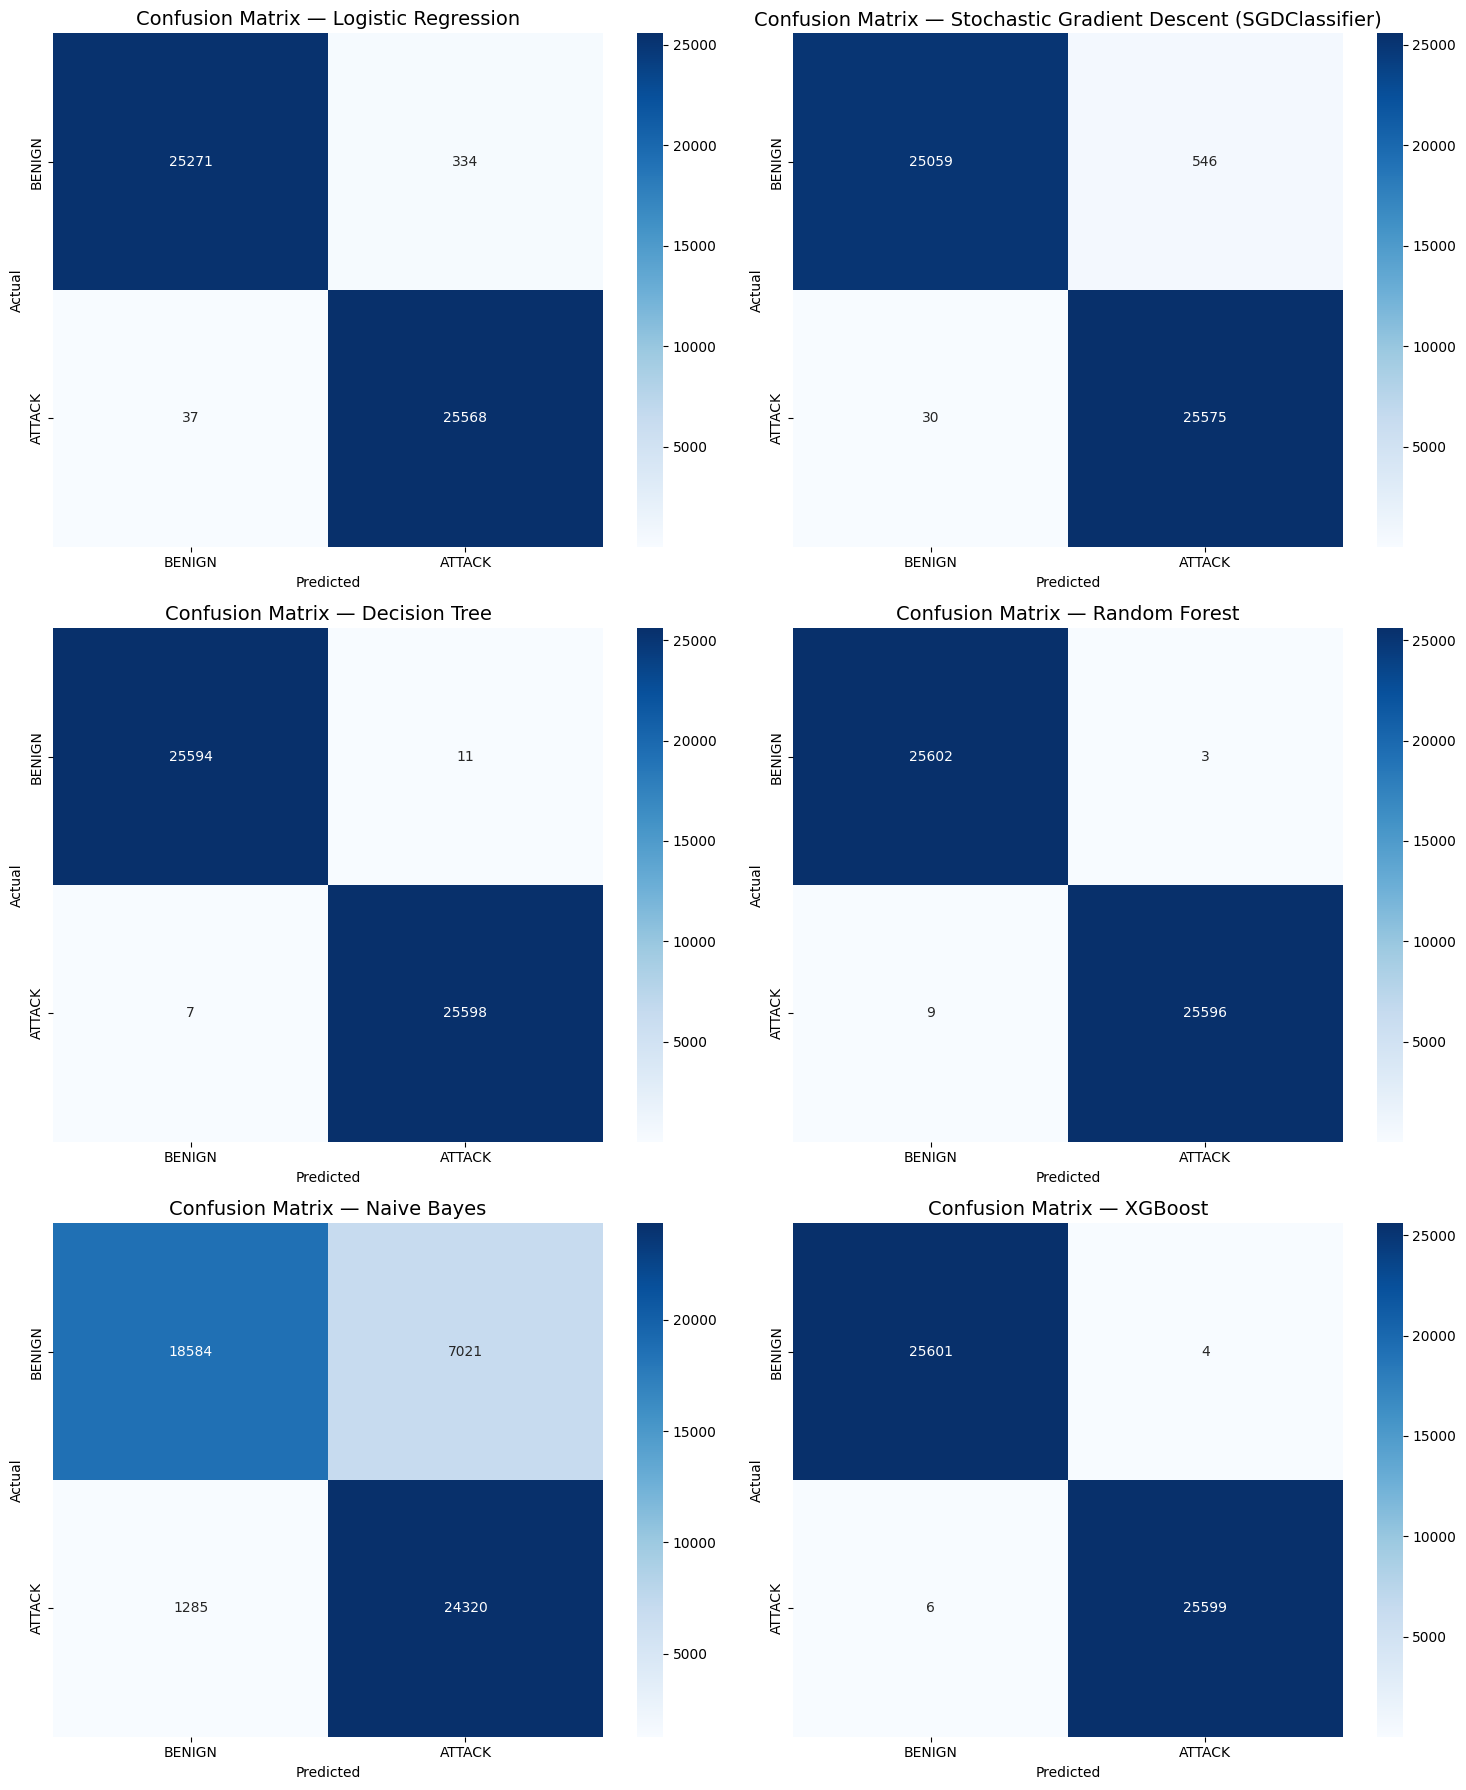

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import math

binary_model_list = list(models.items())
num_models = len(binary_model_list)

cols = 2   # <<< 2 per row
rows = math.ceil(num_models / cols)

plt.figure(figsize=(15, 6 * rows))

plot_index = 1

for name, model in binary_model_list:
    preds = model.predict(X_test_pca)
    cm = confusion_matrix(y_test, preds)

    plt.subplot(rows, cols, plot_index)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["BENIGN", "ATTACK"],
        yticklabels=["BENIGN", "ATTACK"]
    )

    plt.title(f"Confusion Matrix — {name}", fontsize=14)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plot_index += 1

plt.tight_layout()
plt.show()


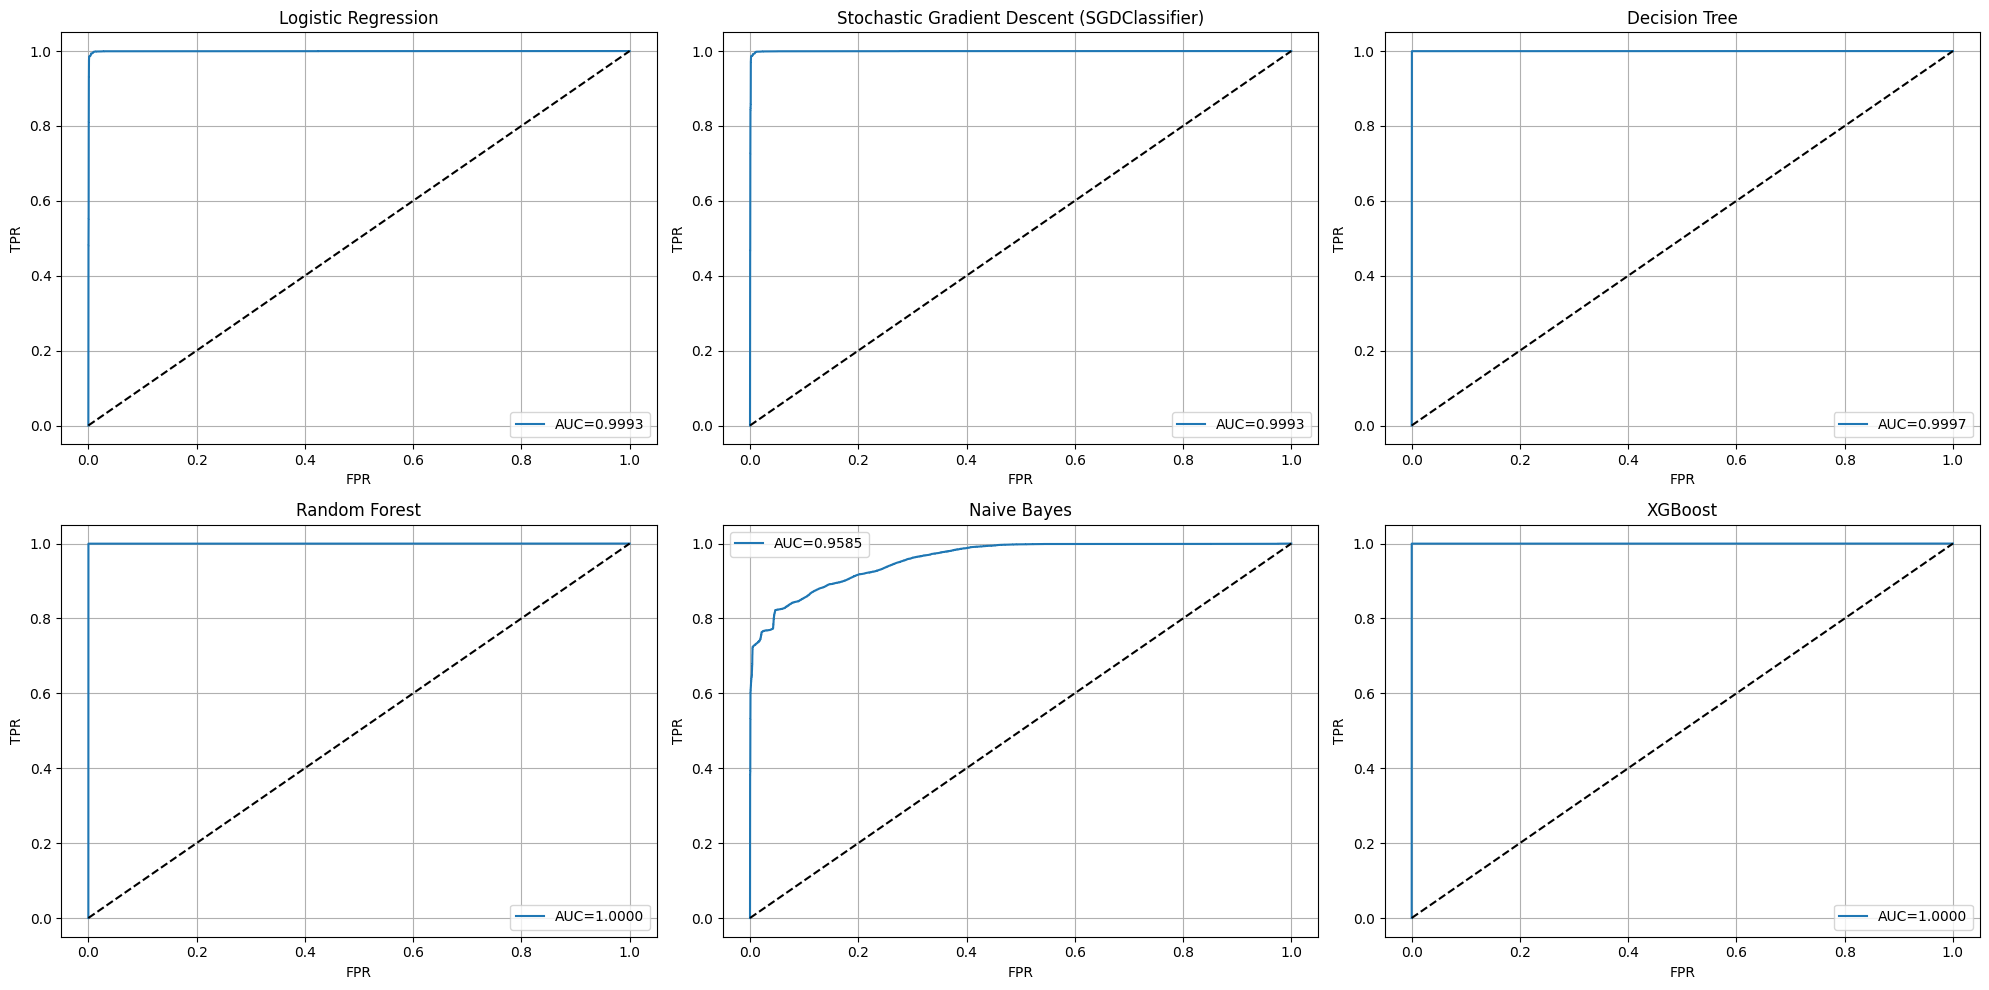

In [52]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import math

binary_model_list = list(models.items())
num_models = len(binary_model_list)

cols = 3   # <<< 3 per row
rows = math.ceil(num_models / cols)

plt.figure(figsize=(20, 5 * rows))

plot_index = 1

for name, model in binary_model_list:
    plt.subplot(rows, cols, plot_index)

    try:
        probs = model.predict_proba(X_test_pca)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, probs)
        auc = roc_auc_score(y_test, probs)

        plt.plot(fpr, tpr, label=f"AUC={auc:.4f}")
        plt.plot([0,1], [0,1], 'k--')

        plt.title(name, fontsize=12)
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.grid(True)
        plt.legend()

    except:
        plt.text(0.5, 0.5, "No predict_proba()", ha="center", va="center")
        plt.title(name)

    plot_index += 1

plt.tight_layout()
plt.show()


**MULTI-CLASS Classification CIC-IDS (Wednesday)**

In [25]:
# MULTI-CLASS CIC-IDS (Wednesday) — Unique Variables

mc_df = pd.read_csv(r"C:\Users\yasha\Downloads\cic-ids\Wednesday-workingHours.pcap_ISCX.csv")
print("Initial shape:", mc_df.shape)

mc_df.columns = mc_df.columns.str.strip()

# Fix label column name if corrupted
if "Label" not in mc_df.columns:
    mc_df.rename(columns={mc_df.columns[-1]: "Label"}, inplace=True)


Initial shape: (692703, 79)


In [26]:
mc_df.replace([np.inf, -np.inf], np.nan, inplace=True)
mc_df.dropna(inplace=True)
print("After cleaning:", mc_df.shape)


After cleaning: (691406, 79)


In [27]:
from sklearn.preprocessing import LabelEncoder

mc_label_encoder = LabelEncoder()
mc_df["Label"] = mc_label_encoder.fit_transform(mc_df["Label"])

print("Multi-class Labels:", mc_label_encoder.classes_)


Multi-class Labels: ['BENIGN' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest' 'DoS slowloris'
 'Heartbleed']


In [28]:
mc_X = mc_df.drop("Label", axis=1)
mc_y = mc_df["Label"]


In [30]:
from sklearn.preprocessing import StandardScaler

mc_scaler = StandardScaler()
mc_X_scaled = mc_scaler.fit_transform(mc_X)


In [31]:
from sklearn.model_selection import train_test_split

mc_X_train, mc_X_test, mc_y_train, mc_y_test = train_test_split(
    mc_X_scaled, mc_y, test_size=0.2, random_state=42, stratify=mc_y
)


In [32]:
from sklearn.decomposition import PCA

mc_pca = PCA(n_components=20, random_state=42)
mc_X_train_pca = mc_pca.fit_transform(mc_X_train)
mc_X_test_pca = mc_pca.transform(mc_X_test)


In [33]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

mc_models = {

    "MC_LogisticRegression": LogisticRegression(
        max_iter=2000,
        multi_class='multinomial',
        solver='lbfgs',
        class_weight='balanced'
    ),

    "MC_SGDClassifier": SGDClassifier(
        loss='log_loss',
        max_iter=2000,
        class_weight='balanced'
    ),

    "MC_DecisionTree": DecisionTreeClassifier(
        max_depth=20,
        class_weight='balanced'
    ),

    "MC_RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=25,
        n_jobs=-1,
        class_weight='balanced'
    ),

    "MC_NaiveBayes": GaussianNB(),

    "MC_XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        tree_method='hist'
    )
}


In [34]:
from sklearn.metrics import accuracy_score, classification_report

for mc_name, mc_model in mc_models.items():
    print("\n==============================")
    print(f"Training {mc_name}...")

    mc_model.fit(mc_X_train_pca, mc_y_train)
    mc_preds = mc_model.predict(mc_X_test_pca)

    mc_acc = accuracy_score(mc_y_test, mc_preds)
    print(f"{mc_name} Accuracy: {mc_acc*100:.2f}%\n")

    print(classification_report(
        mc_y_test, mc_preds, target_names=mc_label_encoder.classes_
    ))



Training MC_LogisticRegression...


C:\Users\yasha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


MC_LogisticRegression Accuracy: 92.65%

                  precision    recall  f1-score   support

          BENIGN       1.00      0.89      0.94     87937
   DoS GoldenEye       0.58      0.99      0.73      2059
        DoS Hulk       0.96      0.99      0.98     46025
DoS Slowhttptest       0.25      0.90      0.39      1100
   DoS slowloris       0.23      0.93      0.37      1159
      Heartbleed       0.67      1.00      0.80         2

        accuracy                           0.93    138282
       macro avg       0.61      0.95      0.70    138282
    weighted avg       0.97      0.93      0.94    138282


Training MC_SGDClassifier...
MC_SGDClassifier Accuracy: 94.29%

                  precision    recall  f1-score   support

          BENIGN       0.97      0.95      0.96     87937
   DoS GoldenEye       0.56      0.91      0.70      2059
        DoS Hulk       0.96      0.94      0.95     46025
DoS Slowhttptest       0.62      0.65      0.64      1100
   DoS slowloris     

In [57]:
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd

def get_metrics_multiclass(model, X, y):
    preds = model.predict(X)

    # Accuracy
    accuracy = accuracy_score(y, preds)

    # Sensitivity = macro recall
    sensitivity = recall_score(y, preds, average="macro")

    # F1 Score = macro
    f1 = f1_score(y, preds, average="macro")

    # Specificity calculation (macro)
    cm = confusion_matrix(y, preds)
    num_classes = cm.shape[0]
    specificities = []

    for i in range(num_classes):
        tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
        fp = cm[:,i].sum() - cm[i,i]
        specificity_i = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(specificity_i)

    specificity = np.mean(specificities)

    # AUC (macro, OvR)
    try:
        probs = model.predict_proba(X)
        y_bin = label_binarize(y, classes=np.unique(y))
        auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
    except:
        auc = np.nan

    return accuracy, sensitivity, specificity, f1, auc

mc_train_rows = []
mc_test_rows = []

for name, model in mc_models.items():
    print(f"Evaluating {name}...")

    # TRAIN metrics
    tr_acc, tr_sens, tr_spec, tr_f1, tr_auc = get_metrics_multiclass(
        model, mc_X_train_pca, mc_y_train
    )
    mc_train_rows.append([
        name,
        f"{tr_acc*100:.2f}%",
        f"{tr_sens*100:.2f}%",
        f"{tr_spec*100:.2f}%",
        f"{tr_f1*100:.2f}%",
        f"{tr_auc:.4f}" if not np.isnan(tr_auc) else "NA"
    ])

    # TEST metrics
    te_acc, te_sens, te_spec, te_f1, te_auc = get_metrics_multiclass(
        model, mc_X_test_pca, mc_y_test
    )
    mc_test_rows.append([
        name,
        f"{te_acc*100:.2f}%",
        f"{te_sens*100:.2f}%",
        f"{te_spec*100:.2f}%",
        f"{te_f1*100:.2f}%",
        f"{te_auc:.4f}" if not np.isnan(te_auc) else "NA"
    ])

# CREATE DATAFRAMES
mc_train_df = pd.DataFrame(mc_train_rows, columns=[
    "Model", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"
])

mc_train_df = mc_train_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n MULTI-CLASS TRAIN METRICS \n")
display(mc_train_df)


mc_test_df = pd.DataFrame(mc_test_rows, columns=[
    "Model", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"
])

mc_test_df = mc_test_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n MULTI-CLASS TEST METRICS \n")
display(mc_test_df)


Evaluating MC_LogisticRegression...
Evaluating MC_SGDClassifier...
Evaluating MC_DecisionTree...
Evaluating MC_RandomForest...
Evaluating MC_NaiveBayes...
Evaluating MC_XGBoost...

 MULTI-CLASS TRAIN METRICS 



,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,MC_RandomForest,99.98%,100.00%,100.00%,99.98%,1.0000
1,MC_XGBoost,99.97%,99.90%,99.99%,99.90%,1.0000
2,MC_DecisionTree,99.77%,99.91%,99.95%,99.12%,0.9999
3,MC_SGDClassifier,94.31%,88.99%,98.39%,64.32%,0.9941
4,MC_LogisticRegression,92.70%,95.14%,98.60%,71.94%,0.9949
5,MC_NaiveBayes,56.57%,70.19%,89.17%,53.70%,0.9467



 MULTI-CLASS TEST METRICS 



,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,MC_XGBoost,99.94%,99.52%,99.98%,99.57%,0.9998
1,MC_RandomForest,99.93%,99.45%,99.98%,99.54%,0.9995
2,MC_DecisionTree,99.71%,99.34%,99.93%,98.62%,0.9970
3,MC_SGDClassifier,94.29%,88.51%,98.38%,64.07%,0.9938
4,MC_LogisticRegression,92.65%,94.91%,98.59%,70.17%,0.9943
5,MC_NaiveBayes,56.71%,69.77%,89.20%,53.61%,0.9456


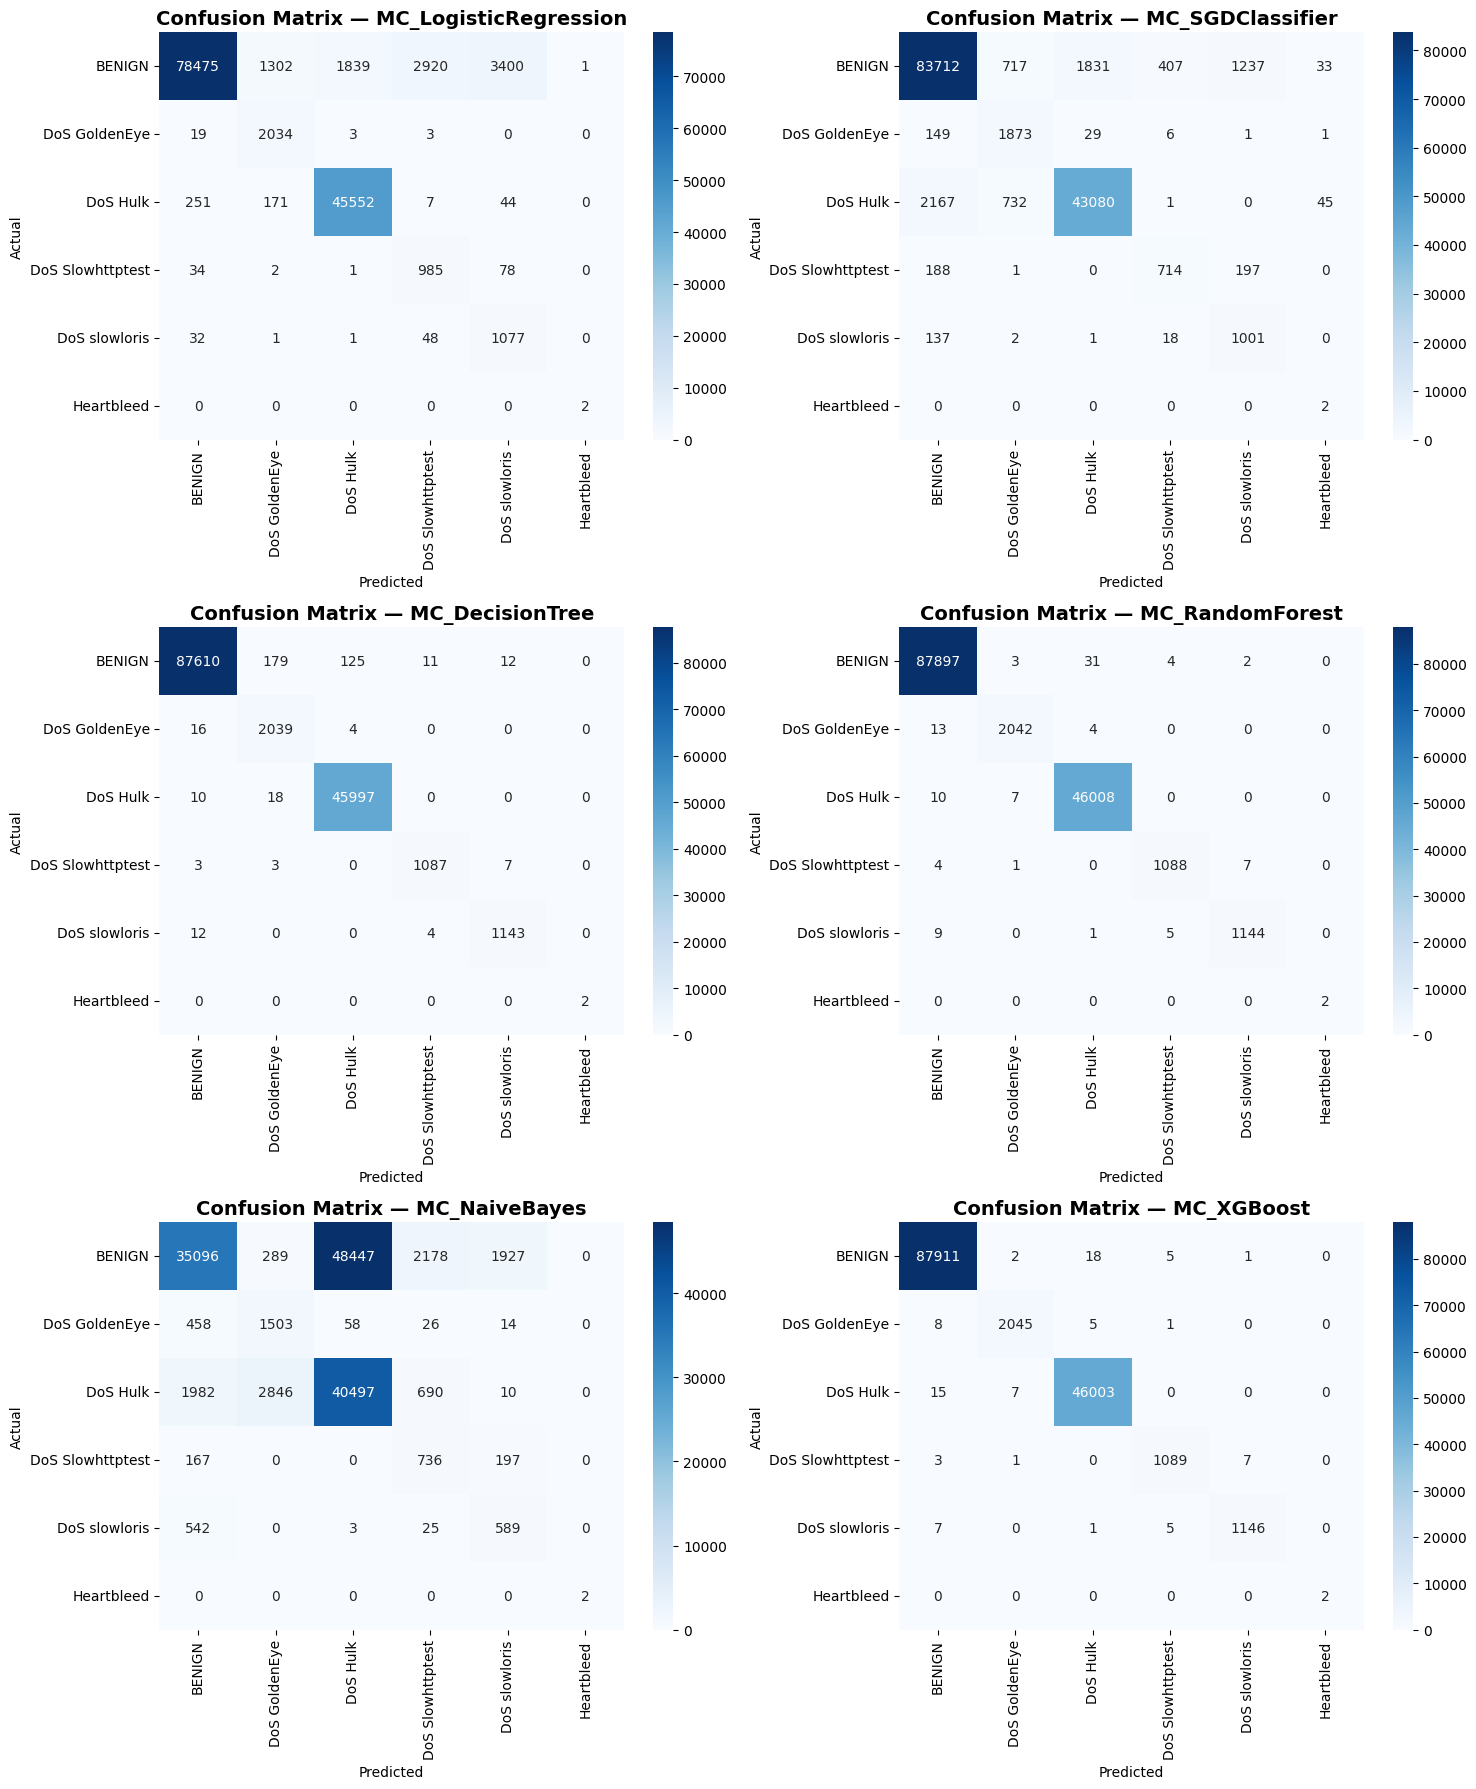

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import math

mc_model_list = list(mc_models.items())
num_models = len(mc_model_list)
cols = 2                          
rows = math.ceil(num_models / cols)

plt.figure(figsize=(15, 6 * rows))  # adjust if needed

plot_index = 1

for mc_name, mc_model in mc_model_list:
    mc_preds = mc_model.predict(mc_X_test_pca)
    mc_cm = confusion_matrix(mc_y_test, mc_preds)

    # subplot (rows x cols)
    plt.subplot(rows, cols, plot_index)

    sns.heatmap(
        mc_cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=mc_label_encoder.classes_,
        yticklabels=mc_label_encoder.classes_
    )

    plt.title(f"Confusion Matrix — {mc_name}", fontsize=14, fontweight="bold")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plot_index += 1

plt.tight_layout()
plt.show()


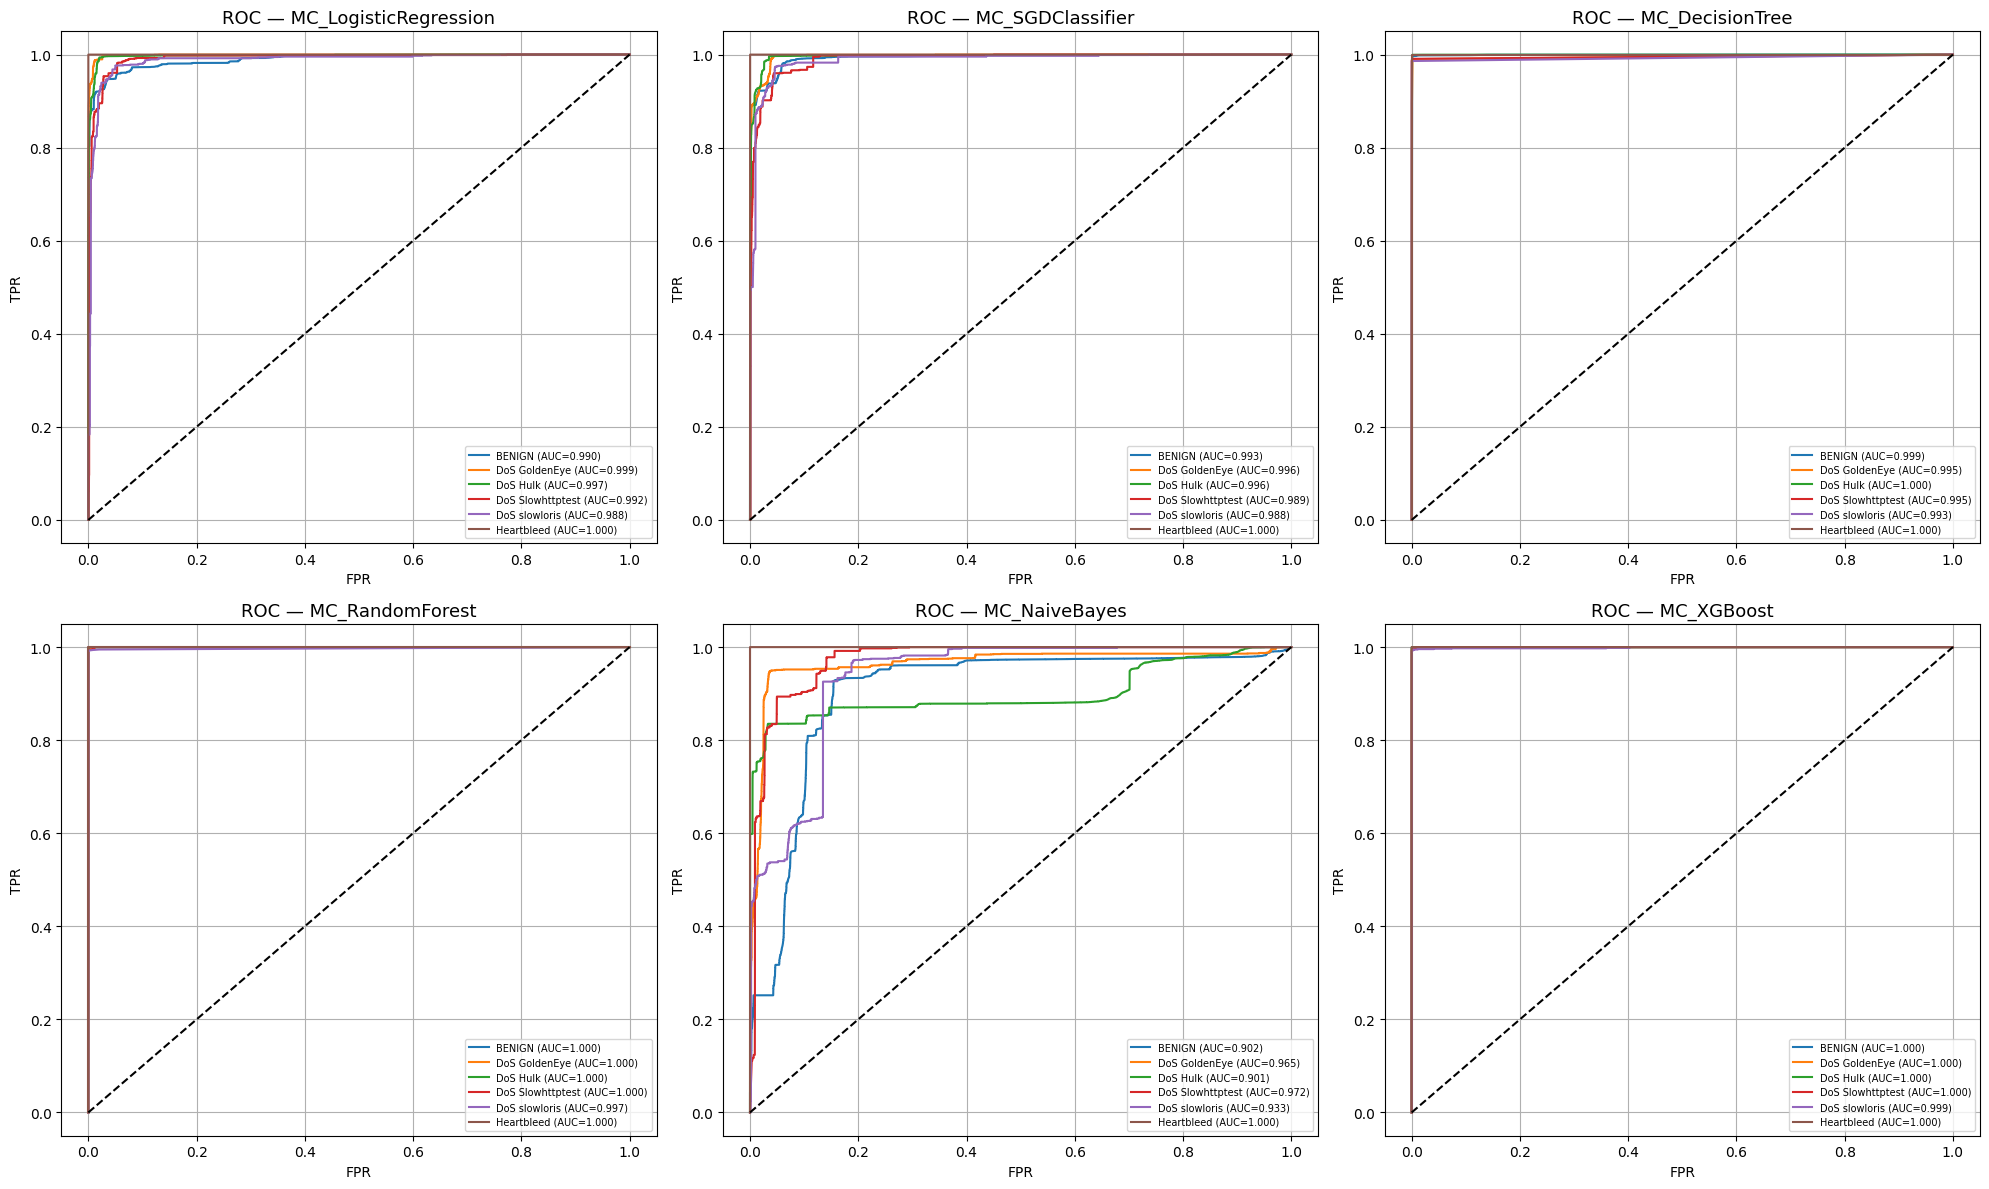

In [47]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import math

# Convert labels to one-hot for OvR ROC
mc_y_test_bin = label_binarize(mc_y_test, classes=np.unique(mc_y_test))
n_classes = mc_y_test_bin.shape[1]
class_names = mc_label_encoder.inverse_transform(np.unique(mc_y_test))

mc_model_list = list(mc_models.items())
num_models = len(mc_model_list)

cols = 3   # <<< 3 ROC curves per row
rows = math.ceil(num_models / cols)

plt.figure(figsize=(20, 6 * rows))   # adjust as needed

plot_index = 1

for mc_name, mc_model in mc_model_list:
    try:
        mc_probs = mc_model.predict_proba(mc_X_test_pca)

        # Create subplot
        plt.subplot(rows, cols, plot_index)

        # Plot ROC for each class inside the subplot
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(mc_y_test_bin[:, i], mc_probs[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")

        plt.plot([0,1], [0,1], 'k--')
        plt.title(f"ROC — {mc_name}", fontsize=13)
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.grid(True)
        plt.legend(fontsize=7)

    except Exception as e:
        plt.subplot(rows, cols, plot_index)
        plt.text(0.5, 0.5, "No predict_proba()", ha="center", va="center")
        plt.title(mc_name)

    plot_index += 1

plt.tight_layout()
plt.show()


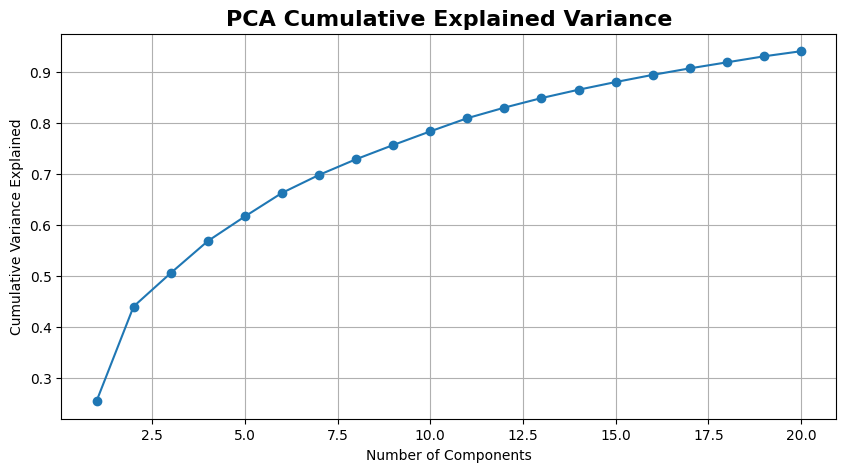

In [35]:
## PCA Explained Variance Plot

plt.figure(figsize=(10,5))
plt.plot(
    range(1, len(mc_pca.explained_variance_ratio_)+1),
    mc_pca.explained_variance_ratio_.cumsum(),
    marker='o'
)

plt.title("PCA Cumulative Explained Variance", fontsize=16, fontweight="bold")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.grid(True)
plt.show()


In [58]:
# -------------------------------
# PREPARE BINARY TABLES
# -------------------------------

binary_train_df = train_df.copy()
binary_train_df["Set"] = "Train"
binary_train_df["Type"] = "Binary"

binary_test_df = test_df.copy()
binary_test_df["Set"] = "Test"
binary_test_df["Type"] = "Binary"

# Combine binary first (this creates the FIRST BLOCK)
binary_block = pd.concat(
    [binary_train_df, binary_test_df],
    ignore_index=True
)

# -------------------------------
# PREPARE MULTI-CLASS TABLES
# -------------------------------

mc_train_df2 = mc_train_df.copy()
mc_train_df2["Set"] = "Train"
mc_train_df2["Type"] = "Multi-Class"

mc_test_df2 = mc_test_df.copy()
mc_test_df2["Set"] = "Test"
mc_test_df2["Type"] = "Multi-Class"

# Combine multi-class (SECOND BLOCK)
multi_block = pd.concat(
    [mc_train_df2, mc_test_df2],
    ignore_index=True
)

# -------------------------------
# CONCATENATE IN ORDER
# -------------------------------

final_results_df = pd.concat(
    [binary_block, multi_block],  
    ignore_index=True
)

# -------------------------------
# SAVE FILE
# -------------------------------

final_results_df.to_json(
    "CICIDS_All_Results.json",
    orient="records",    # array of objects (clean format)
    indent=4
)

